# **Pension fund simulated/simplified portfolio optimization model**
## **Students:**
- **Durmishkhan Gigineishvili**
- **Saba Zazadze**
### *Note: This Jupyter notebook ,though is primarily for codes but it is still well-commented for clearly demonstrating what's done there*
- Also please do not change order of cell execution since errors may occur like tables confusion with each other.
- We tried to make the codes as readable and logical as possible given complexity of our model we came up with, especially coming from the constraints, scenarios, combined tables and other parts

# Importing relevant libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyomo.environ as pyo
from pyomo.contrib.appsi.solvers import Highs
from pyomo.environ import Suffix

## Definition of asset we used in our simulated pension fund portfolio model:

This dataset contains monthly returns for the following assets:

### Equity ETFs
- **INTC** – Intel Corporation stock (US semiconductor company)
- **SPY** – SPDR S&P 500 ETF (tracks S&P 500 index)
- **IVV** – iShares Core S&P 500 ETF (tracks S&P 500 index)
- **VGK** – Vanguard FTSE Europe ETF (developed European equities)
- **VPL** – Vanguard FTSE Pacific ETF (developed Asia-Pacific equities)
- **VWO** – Vanguard FTSE Emerging Markets ETF
- **EWY** – iShares MSCI South Korea ETF
- **ILF** – iShares Latin America 40 ETF

### Bonds
- **IEF** – iShares 7–10 Year Treasury Bond ETF
- **TLT** – iShares 20+ Year Treasury Bond ETF

### Georgian Assets
- **BOG** – Bank of Georgia Group PLC stock
- **TBC** – TBC Bank Group PLC stock
- **CGEO** – Georgia Capital PLC stock

### Consumer Stock
- **KO** – Coca-Cola Company stock

---

## Additional Notes and model assumptions
- All assets are going to be expressed in **monthly returns**
- Equity ETFs represent regional diversification as you know they are linked with hundreeds of stocks or bonds respectively in a regional market
- Bonds provide duration and risk hedging so that's why we also considered them like in real pension funds
- **Georgian related equities are considered as domestic assets, it's probably strict assumption but our data constraint made us come up with such assumption**

# **Model definition:**

# Mean Absolute Deviation (MAD) Portfolio Optimization Model

We construct a portfolio optimization model over a set of assets, minimizing Mean Absolute Deviation (MAD) of returns subject to realistic investment constraints.

---

## Assets

The portfolio consists of the following assets:

```python
['INTC', 'KO', 'SPY', 'IVV', 'VGK', 'VPL', 'VWO', 'EWY',
 'ILF', 'IEF', 'TLT', 'BOG', 'TBC', 'CGEO']

- `constraint 1:` **Weights add up to one** *(Budget constraint)*
- `constraint 2:` **Weights of equity assets cannot exceed 0.1** *(For ensuring diversification)*
- `constraint 3:` **Weights of bonds cannot exceed 0.12** *(For ensuring diversification)*
- `constraint 4:` **Weight of domestic assets have to be combined at least 0.1** *(For suporting domestic stocks)*
- `constraint 5:` **Weight of bonds have to be at least 0.2** *(For lowering risks of repayment, bond owners are paid first)*
- `constraint 6:` **Minimum required return in baseline model 0.04 annually** (USD inflation is around 3% expected annually in worst case scenario, we want **real positive return**)
- `constraint 7:` **All weights are non-negative**

# **Data transformation and EDA(Exploratory data analysis)**

# Loading the dataset

In [2]:
prices = pd.read_csv("pension_fund_dataset.csv")

# show column names
print(prices.columns)

Index(['Date', 'INTC', 'KO', 'SPY', 'IVV', 'VGK', 'VPL', 'VWO', 'EWY', 'ILF',
       'IEF', 'TLT', 'BOG', 'TBC', 'CGEO'],
      dtype='str')


In [3]:
prices.head()

,Date,INTC,KO,SPY,IVV,VGK,VPL,VWO,EWY,ILF,IEF,TLT,BOG,TBC,CGEO
0,2018-05-29 00:00:00,55.320000,42.680000,269.019989,270.929993,57.119999,72.269997,44.169998,72.669998,31.280001,103.000000,122.239998,24.817578,21.384821,14.828229
1,2018-05-30 00:00:00,55.680000,43.130001,272.609985,274.549988,58.150002,72.779999,44.560001,72.519997,31.549999,102.559998,121.419998,24.291584,21.762757,12.992710
2,2018-05-31 00:00:00,55.200001,43.000000,270.940002,272.730011,57.959999,72.389999,44.610001,72.139999,31.389999,102.510002,121.220001,24.877459,21.971015,13.352639
3,2018-06-01 00:00:00,57.080002,43.119999,273.600006,275.529999,58.450001,73.010002,45.110001,73.480003,31.490000,101.930000,120.300003,26.206679,22.326177,14.153201
4,2018-06-04 00:00:00,56.830002,43.490002,274.899994,276.809998,58.580002,73.459999,45.580002,73.779999,31.980000,101.570000,119.430000,28.175503,22.438893,14.425003


### As you can see we have end day prices for the stocks and bond ETF's daily

# Converting daily data to monthly returns:
- Returns calculated at the end of each month by finding what was percentage increase in price relative to end of previous month
- ((**P**t-**P**t-1)/**P**t-1)-1

In [4]:
prices = pd.read_csv("pension_fund_dataset.csv")

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values("Date")
prices = prices.set_index("Date")

monthly_prices = prices.resample("ME").last()

monthly_returns = monthly_prices.pct_change().iloc[1:]

print(monthly_returns.shape)

(91, 14)


- So we have return for 91 months 7.5 years(**Note that actually in dataset there are 92 months from may 2018 ro december 2025 but that happens because we cannot calculate return for May 2018 as April 2018 prices are not in our data**). That data is till 2025 december 31th, and it starts from may 2018 (*though returns as previously mentioned reason start from June*) as in that month all of the assets were listed on yahoo finance, especially `BOG`, `TBC` and `CGEO` that joined international stock markets relatively later than other assets.

In [5]:
monthly_returns.head()

,INTC,KO,SPY,IVV,VGK,VPL,VWO,EWY,ILF,IEF,TLT,BOG,TBC,CGEO
Date,,,,,,,,,,,,,,
2018-06-30,-0.099457,0.020000,0.001255,0.001173,-0.031573,-0.033292,-0.054024,-0.061408,-0.057343,0.000000,0.004125,-0.009278,0.039060,0.008594
2018-07-31,-0.032388,0.063156,0.037047,0.037466,0.034028,0.008002,0.039810,-0.006646,0.112538,-0.007121,-0.016596,-0.027260,0.011515,-0.035964
2018-08-31,0.006861,-0.044178,0.031920,0.032336,-0.028256,-0.009498,-0.041933,0.000892,-0.083232,0.008155,0.010861,-0.102924,-0.098496,0.029011
2018-09-30,-0.023539,0.036347,0.001412,0.000992,-0.003191,0.017604,-0.024738,0.014112,0.040093,-0.014034,-0.030826,0.040719,0.057979,0.092138
2018-10-31,-0.008670,0.036588,-0.069104,-0.068220,-0.078975,-0.099015,-0.076585,-0.146477,0.048105,-0.005041,-0.031466,-0.114582,-0.024815,0.019107


### Summary table using describe function:

In [6]:
monthly_returns.describe()

,INTC,KO,SPY,IVV,VGK,VPL,VWO,EWY,ILF,IEF,TLT,BOG,TBC,CGEO
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,0.001957,0.006631,0.011367,0.011346,0.005431,0.003441,0.003181,0.006065,0.003109,-0.000499,-0.002746,0.026529,0.017178,0.018538
std,0.113449,0.050338,0.048506,0.048567,0.052950,0.044800,0.047537,0.075368,0.081164,0.020271,0.042077,0.127514,0.116559,0.106586
min,-0.310165,-0.172743,-0.129987,-0.126762,-0.171992,-0.111755,-0.172014,-0.182179,-0.347391,-0.049039,-0.095624,-0.480923,-0.462208,-0.394743
25%,-0.050787,-0.020190,-0.014473,-0.014439,-0.030893,-0.013764,-0.030981,-0.046981,-0.046821,-0.013626,-0.031162,-0.047984,-0.045848,-0.029645
50%,0.004082,0.012985,0.019093,0.019613,0.016561,0.007325,0.007432,0.006960,0.004207,0.000525,-0.003682,0.024745,0.012840,0.025026
75%,0.064021,0.036825,0.041143,0.040948,0.039182,0.031784,0.032116,0.046713,0.049766,0.010199,0.022559,0.106548,0.075393,0.089980
max,0.377823,0.128885,0.126984,0.126780,0.163944,0.131601,0.143018,0.210986,0.249881,0.042639,0.108285,0.325384,0.343911,0.345782


# Let's observe distribution of these asset returns:

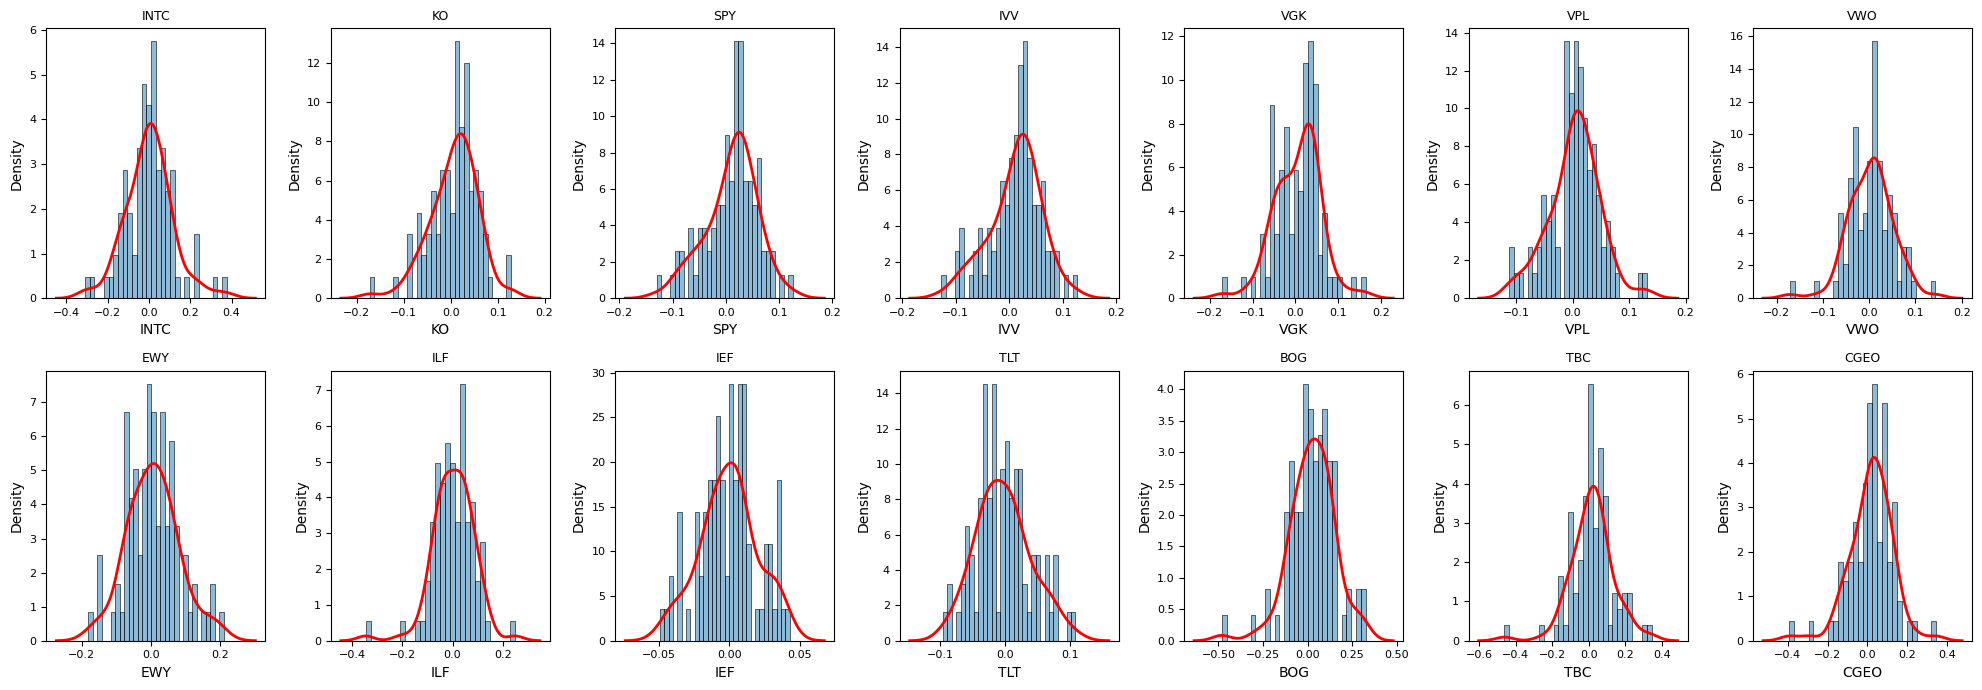

In [7]:
num_cols = monthly_returns.select_dtypes(include="number").columns

fig, axes = plt.subplots(2, 7, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols): # "for" loop we use to graph the distribution of all variables in columns with density line too
    data = monthly_returns[col].dropna()

    # histograms
    sns.histplot(data, bins=30, stat="density", ax=axes[i], alpha=0.5)

    # density line (this is kde plot)
    sns.kdeplot(data, ax=axes[i], color="red", linewidth=2)

    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='both', labelsize=8)

# remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Building our first model:**
### Primal problem

In [8]:
# 1. Preparing the data
R = monthly_returns.copy() # here we just copied the dataset because we didnt want to modify initial dataset, and we'll keep this method for future codes too

assets = R.columns.tolist() # This gives us the column names as a list
T = R.shape[0]

mu = R.mean() # mean return of each asset (we actually used this as proxy for expected return, so we expect future return based on past experience)

# 2. Setting the model up
model = pyo.ConcreteModel() # Here we're creating pyomo optimization model

model.I = pyo.Set(initialize=assets)
model.T = pyo.RangeSet(0, T - 1)

# 3. Defining the decision variabeles
model.w = pyo.Var(model.I, domain=pyo.NonNegativeReals)   # portfolio weights
model.z = pyo.Var(model.T, domain=pyo.NonNegativeReals)    # MAD deviations

# 4. Our objective function (We're minimizing MAD, which stands for mean average deviation)
def objective_rule(m):
    return sum(m.z[t] for t in m.T)

model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

# 5. Now let's define our constraintss  (In the 5th section below we're creating our functions based on which our model will make decisions)

# 5.1 Budget constraint:
def budget_rule(m):
    return sum(m.w[i] for i in m.I) == 1

model.budget = pyo.Constraint(rule=budget_rule)

# 5.2 MAD linearization:
def dev_pos_rule(m, t):
    return m.z[t] >= sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)

def dev_neg_rule(m, t):
    return m.z[t] >= -sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)

model.dev_pos = pyo.Constraint(model.T, rule=dev_pos_rule)
model.dev_neg = pyo.Constraint(model.T, rule=dev_neg_rule)

# 5.3 Defining Asset caps
bonds = ["IEF", "TLT"]

def cap_rule(m, i):
    if i in bonds:                # The logic of our "if loop" is following: we want to apply 0.1 cap to all assets different from Bond ETF's.
        return pyo.Constraint.Skip
    return m.w[i] <= 0.1

model.cap = pyo.Constraint(model.I, rule=cap_rule)

bond_cap = {"IEF": 0.12, "TLT": 0.12} # We define bond caps as a dictionary

def bond_cap_rule(m, i):
    if i in bond_cap:             # Now this "if" loop is giving a cap according to our dictionary if asset is listed as bond 
        return m.w[i] <= bond_cap[i]    
    return pyo.Constraint.Skip

model.bond_cap = pyo.Constraint(model.I, rule=bond_cap_rule)

# 5.4 Domestic constraints
domestic = ["BOG", "TBC", "CGEO"] # this is list of assets we consider Domestic by assumption though u know they operate on London Stock exchange 
epsilon = 0.01

def domestic_total_rule(m):
    return sum(m.w[i] for i in domestic) >= 0.1

model.domestic = pyo.Constraint(rule=domestic_total_rule)

def domestic_min_rule(m, i):
    if i in domestic:
        return m.w[i] >= epsilon
    return pyo.Constraint.Skip

model.domestic_min = pyo.Constraint(model.I, rule=domestic_min_rule)

# 5.5 Bond constraint
def bond_rule(m):
    return sum(m.w[i] for i in bonds) >= 0.2

model.bonds = pyo.Constraint(rule=bond_rule)

# 5.6 Target return constraint
target_annual = 0.04
target_monthly = (1 + target_annual) ** (1 / 12) - 1 # here we used compounding formula

def target_return_rule(m):
    return sum(m.w[i] * mu[i] for i in m.I) >= target_monthly

model.target_return = pyo.Constraint(rule=target_return_rule)

# 6. Solving ou r model:
opt = Highs()
result = opt.solve(model)

# 7. Obtaining the results finally!:
weights_base = pd.Series({i: pyo.value(model.w[i]) for i in model.I})

print("\nOptimal Portfolio Weights:\n")

weights_df = weights_base.sort_values(ascending=False).to_frame("Weight").reset_index()
weights_df.columns = ["Asset", "Weight"]

print(weights_df)


Optimal Portfolio Weights:

   Asset    Weight
0    TLT  0.120000
1    IEF  0.120000
2    VGK  0.100000
3    IVV  0.100000
4     KO  0.100000
5    SPY  0.100000
6    VWO  0.100000
7    VPL  0.100000
8   CGEO  0.051592
9    ILF  0.049998
10   TBC  0.038408
11  INTC  0.010002
12   BOG  0.010000
13   EWY  0.000000


- **Note that 0-13 is index , in total there are 14 results**

- As you might notice corner point optimal weights w.r.t. constraints are frequent for bonds and ETF stocks too, only ILF stock , intel and domestic ones are exception.

# Portfolio Performance Summary Table:
- This is for 4% min required return, in the next step we'll conduct sensitivity analysis for that variable.

In [9]:
portfolio_returns = monthly_returns @ weights_base  # Portfolio return series obtained from asset returns and optimal weights

expected_monthly_return = portfolio_returns.mean()  # Average monthly portfolio return

expected_annual_return = (
    (1 + expected_monthly_return) ** 12 - 1
)  # Annualized return using compounding

monthly_std = portfolio_returns.std()  # Monthly volatility

annualized_std = monthly_std * np.sqrt(12)  # Annualized volatility

mad = np.mean(
    np.abs(
        portfolio_returns - portfolio_returns.mean()
    )
)  # Mean Absolute Deviation (MAD) of portfolio returns

best_month = portfolio_returns.max()  # Highest monthly return observed

worst_month = portfolio_returns.min()  # Lowest monthly return observed


portfolio_summary = pd.DataFrame({  # Summary table of portfolio performance
    "Metric": [
        "Expected Monthly Return",
        "Expected Annual Return",
        "Monthly Std Dev",
        "Annualized Std Dev",
        "MAD",
        "Best Month",
        "Worst Month"
    ],
    "Value": [
        expected_monthly_return,
        expected_annual_return,
        monthly_std,
        annualized_std,
        mad,
        best_month,
        worst_month
    ]
})

print("\nPortfolio Performance Summary\n")
print(portfolio_summary)


cumulative_growth = (
    1 + portfolio_returns
).cumprod()  # this is actually for growth of $1 invested over time


asset_std = monthly_returns.std()  # Standard deviation of each asset

asset_mad = monthly_returns.apply(
    lambda x: np.mean(np.abs(x - x.mean()))
)  # Mean Absolute Deviation for each asset


risk_table = pd.DataFrame({
    "Assets": asset_std.index,
    "Std_Dev": asset_std.values,
    "MAD": asset_mad.values
})

risk_table["Std_Rank"] = risk_table["Std_Dev"].rank(
    ascending=False
)

risk_table["MAD_Rank"] = risk_table["MAD"].rank(
    ascending=False
)

risk_table = risk_table.sort_values(
    "Std_Dev",
    ascending=False
)

print("\nAsset Risk Summary\n")
print(risk_table)


Portfolio Performance Summary

                    Metric     Value
0  Expected Monthly Return  0.005807
1   Expected Annual Return  0.071952
2          Monthly Std Dev  0.037517
3       Annualized Std Dev  0.129962
4                      MAD  0.028179
5               Best Month  0.115600
6              Worst Month -0.137291

Asset Risk Summary

   Assets   Std_Dev       MAD  Std_Rank  MAD_Rank
11    BOG  0.127514  0.095171       1.0       1.0
12    TBC  0.116559  0.083364       2.0       2.0
0    INTC  0.113449  0.083058       3.0       3.0
13   CGEO  0.106586  0.077268       4.0       4.0
8     ILF  0.081164  0.061001       5.0       5.0
7     EWY  0.075368  0.058314       6.0       6.0
4     VGK  0.052950  0.041957       7.0       7.0
1      KO  0.050338  0.038461       8.0       8.0
3     IVV  0.048567  0.037556       9.0       9.0
2     SPY  0.048506  0.037486      10.0      10.0
6     VWO  0.047537  0.036077      11.0      11.0
5     VPL  0.044800  0.033445      12.0      12.0
1

- ### BOG has the most risky/volatile stock so that's why only our assumption that it should get supported and get 1% of funding made it part of the portfolio.

# **Dual problem solving**
## Dual Values (Shadow Prices)
### **`Important note:`**
<span style="color:orange; font-size:24px;">
This code does not explicitly formulate and solve the dual optimization problem. Instead, it solves the primal MAD portfolio optimization model and retrieves the corresponding dual variables (shadow prices) from the solver using Pyomo's `dual` suffix.

For linear programming problems, these shadow prices are the optimal values of the dual variables associated with each primal constraint. Therefore, the results provide the same economic interpretation as the dual solution without requiring the dual model to be written explicitly.

An explicit dual formulation was not implemented because the MAD portfolio model contains a large number of constraints, particularly the deviation constraints used to linearize the absolute values. Since the dual problem requires one dual variable for every primal constraint and one dual constraint for every primal variable, the resulting dual model would be considerably larger and more cumbersome to derive, implement, verify, and maintain.

Using the solver-provided shadow prices is the standard approach in practice because it yields the optimal dual values directly while avoiding the complexity of manually constructing the full dual optimization problem.
</span>

In [10]:
# 1. Preparing the data
R = monthly_returns.copy()

assets = R.columns.tolist()
T = len(R)

mu = R.mean()
# 1.1 defining lists for bond ETFs and domestic stocks
bonds = ["IEF", "TLT"]
domestic = ["BOG", "TBC", "CGEO"]

bond_cap = {"IEF": 0.12, "TLT": 0.12}
#1.2 definindg the variables we'll need ahead taking into acc. experience from primal code
epsilon = 0.01

target_annual = 0.04
target_monthly = (1 + target_annual) ** (1 / 12) - 1


# 2. Setting the model up
m = pyo.ConcreteModel()

m.I = pyo.Set(initialize=assets)
m.T = pyo.RangeSet(0, T - 1)


# 3. Defining the decision variables
m.w = pyo.Var(m.I, domain=pyo.NonNegativeReals)  # portfolio weights
m.z = pyo.Var(m.T, domain=pyo.NonNegativeReals)  # MAD deviations


# 4. Defining the objective function (Minimize MAD)
m.obj = pyo.Objective(
    expr=sum(m.z[t] for t in m.T),
    sense=pyo.minimize
)


# 5. Now let's define our constraints

# 5.1 Budget constraint
m.budget = pyo.Constraint(
    expr=sum(m.w[i] for i in m.I) == 1
)

# 5.2 MAD linearization constraints
m.dev_pos = pyo.Constraint(
    m.T,
    rule=lambda m, t:
        m.z[t] >= sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
)

m.dev_neg = pyo.Constraint(
    m.T,
    rule=lambda m, t:
        m.z[t] >= -sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
)

# 5.3 Asset caps
m.cap = pyo.Constraint(
    m.I,
    rule=lambda m, i:
        pyo.Constraint.Skip if i in bonds else m.w[i] <= 0.10
)

m.bond_cap = pyo.Constraint(
    m.I,
    rule=lambda m, i:
        m.w[i] <= bond_cap[i] if i in bond_cap else pyo.Constraint.Skip
)

# 5.4 Domestic constraints
m.domestic = pyo.Constraint(
    expr=sum(m.w[i] for i in domestic) >= 0.10
)

m.domestic_min = pyo.Constraint(
    m.I,
    rule=lambda m, i:
        m.w[i] >= epsilon if i in domestic else pyo.Constraint.Skip
)

# 5.5 Bond constraint
m.bonds = pyo.Constraint(
    expr=sum(m.w[i] for i in bonds) >= 0.20
)

# 5.6 Target return constraint
m.target = pyo.Constraint(
    expr=sum(m.w[i] * mu[i] for i in m.I) >= target_monthly
)


# 6. Setting up dual variables (Must be done before solving)
m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)


# 7. Solving the model
solver = pyo.SolverFactory("highs")
result = solver.solve(m, load_solutions=True)

print("\nSolver Status:", result.solver.status)
print("Termination Condition:", result.solver.termination_condition)


# 8. Exploring shadow prices (Dual Variables)

print("\nShadow Prices (Dual Values)\n")


# 8.1 Getting portfoilo level constraints:
print("Portfolio Constraints")
print("-" * 50)

print(f"Budget Constraint      : {m.dual.get(m.budget, 0):.6f}")
print(f"Bond Minimum           : {m.dual.get(m.bonds, 0):.6f}")
print(f"Domestic Constraint    : {m.dual.get(m.domestic, 0):.6f}")
print(f"Target Return          : {m.dual.get(m.target, 0):.6f}")


# 8.2 Equity cap constraints
print("\nEquity Cap Constraints")
print("-" * 50)

for i in assets:
    if i not in bonds:
        print(
            f"{i:<5} | "
            f"Weight = {pyo.value(m.w[i]):.6f} | "
            f"Cap = 0.100000 | "
            f"Dual = {m.dual.get(m.cap[i], 0):.6f}"
        )


# 8.3 Bond cap constraints
print("\nBond Cap Constraints")
print("-" * 50)

for i in bonds:
    print(
        f"{i:<5} | "
        f"Weight = {pyo.value(m.w[i]):.6f} | "
        f"Cap = {bond_cap[i]:.6f} | "
        f"Dual = {m.dual.get(m.bond_cap[i], 0):.6f}"
    )


#8.4 Domestic minimum constraints
print("\nDomestic Minimum Constraints")
print("-" * 50)

for i in domestic: # This for loop prints domestic min. constr related duals
    print(
        f"{i:<5} | "
        f"Weight = {pyo.value(m.w[i]):.6f} | "
        f"Minimum = {epsilon:.6f} | "
        f"Dual = {m.dual.get(m.domestic_min[i], 0):.6f}"
    )


Solver Status: ok
Termination Condition: optimal

Shadow Prices (Dual Values)

Portfolio Constraints
--------------------------------------------------
Budget Constraint      : 4.137273
Bond Minimum           : -0.000000
Domestic Constraint    : 0.376345
Target Return          : -0.000000

Equity Cap Constraints
--------------------------------------------------
INTC  | Weight = 0.010002 | Cap = 0.100000 | Dual = -0.000000
KO    | Weight = 0.100000 | Cap = 0.100000 | Dual = -1.938586
SPY   | Weight = 0.100000 | Cap = 0.100000 | Dual = -1.257486
IVV   | Weight = 0.100000 | Cap = 0.100000 | Dual = -1.246534
VGK   | Weight = 0.100000 | Cap = 0.100000 | Dual = -0.725446
VPL   | Weight = 0.100000 | Cap = 0.100000 | Dual = -1.265455
VWO   | Weight = 0.100000 | Cap = 0.100000 | Dual = -1.502690
EWY   | Weight = 0.000000 | Cap = 0.100000 | Dual = -0.000000
ILF   | Weight = 0.049998 | Cap = 0.100000 | Dual = -0.000000
BOG   | Weight = 0.010000 | Cap = 0.100000 | Dual = -0.000000
TBC   | Weight

- ### **This is actually very informative because as we can see domestic and budget constraints are binding(That's completely expected), especially domestic minimum investment requirement.**
- ### **Bond minimum and target return are not binding which could also infer from portfolio result analysis (That's what 0's tell us**
- ### **Bond and equity caps are also negative meaning our model wants them to be less restricted**

# **Building table for portfolio weight Sensitivity with respect to target return:**

In [11]:
# 1. Preparing the data
R = monthly_returns.copy()

assets = R.columns.tolist()
T = len(R)

mu = R.mean()

bonds = ["IEF", "TLT"]
domestic = ["BOG", "TBC", "CGEO"]

bond_cap = {"IEF": 0.12, "TLT": 0.12}
epsilon = 0.01


# 2. Defining the model function
# (Bewlo we actually turn the model into a function because we will run it for different target returns)

def solve_portfolio(target_annual):

    target_monthly = (1 + target_annual) ** (1 / 12) - 1  # compounding conversion

    # 2.1 Setting the model up
    m = pyo.ConcreteModel()

    m.I = pyo.Set(initialize=assets)
    m.T = pyo.RangeSet(0, T - 1)

    # 2.2 Defining decision variables
    m.w = pyo.Var(m.I, domain=pyo.NonNegativeReals)   # portfolio weights
    m.z = pyo.Var(m.T, domain=pyo.NonNegativeReals)   # MAD deviations

    # 2.3 Objective function (we minimize MAD as before)
    m.obj = pyo.Objective(expr=sum(m.z[t] for t in m.T), sense=pyo.minimize)

    # 2.4 Budget constraint
    m.budget = pyo.Constraint(expr=sum(m.w[i] for i in m.I) == 1)

    # 2.5 MAD linearization
    m.dev_pos = pyo.Constraint(m.T, rule=lambda m, t:
        m.z[t] >= sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
    )

    m.dev_neg = pyo.Constraint(m.T, rule=lambda m, t:
        m.z[t] >= -sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
    )

    # 2.6 Asset caps
    m.cap = pyo.Constraint(m.I, rule=lambda m, i:
        pyo.Constraint.Skip if i in bonds else m.w[i] <= 0.10
    )

    m.bond_cap = pyo.Constraint(m.I, rule=lambda m, i:
        m.w[i] <= bond_cap[i] if i in bond_cap else pyo.Constraint.Skip
    )

    # 2.7 Domestic constraints
    m.domestic = pyo.Constraint(expr=sum(m.w[i] for i in domestic) >= 0.10)

    m.domestic_min = pyo.Constraint(m.I, rule=lambda m, i:
        m.w[i] >= epsilon if i in domestic else pyo.Constraint.Skip
    )

    # 2.8 Bond constraint
    m.bonds = pyo.Constraint(expr=sum(m.w[i] for i in bonds) >= 0.20)

    # 2.9 Target return constraint (this changes in sensitivity analysis)
    m.target = pyo.Constraint(
        expr=sum(m.w[i] * mu[i] for i in m.I) >= target_monthly
    )

    # 2.10 Solving the model
    Highs().solve(m)

    # 2.11 Extracting results
    w = pd.Series({i: pyo.value(m.w[i]) for i in m.I})

    # 2.12 Returning results for each scenario
    return {
        "Target Annual Return": target_annual,
        "Expected Annual Return": (1 + np.dot(w, mu)) ** 12 - 1,
        "MAD": sum(pyo.value(m.z[t]) for t in m.T) / T,
        **w.to_dict()
    }
# Here is the sensiticity analysis list of targets:
targets = [0.04, 0.05, 0.06, 0.08, 0.09, 0.10]

results = pd.DataFrame([solve_portfolio(t) for t in targets])

# The summary table
summary = results[
    ["Target Annual Return",
     "Expected Annual Return",
     "MAD"]
]

print("\nPortfolio Sensitivity Summary\n")
print(summary.round(4))

# The weights table:
weights = results.set_index("Target Annual Return").drop(
    columns=["Expected Annual Return", "MAD"]
)

# ordering assets by average allocation across scenarios, so that we can more easily see the differences across different scenarios
order = weights.mean().sort_values(ascending=False).index
weights = weights[order]

print("\nScenario Weights\n")
print(weights.T.round(4))


Portfolio Sensitivity Summary

   Target Annual Return  Expected Annual Return     MAD
0                  0.04                   0.072  0.0282
1                  0.05                   0.072  0.0282
2                  0.06                   0.072  0.0282
3                  0.08                   0.080  0.0284
4                  0.09                   0.090  0.0291
5                  0.10                   0.100  0.0302

Scenario Weights

Target Annual Return    0.04    0.05    0.06    0.08    0.09    0.10
TLT                   0.1200  0.1200  0.1200  0.1200  0.1200  0.1200
IEF                   0.1200  0.1200  0.1200  0.1200  0.1200  0.1200
VPL                   0.1000  0.1000  0.1000  0.1000  0.1000  0.1000
IVV                   0.1000  0.1000  0.1000  0.1000  0.1000  0.1000
KO                    0.1000  0.1000  0.1000  0.1000  0.1000  0.1000
SPY                   0.1000  0.1000  0.1000  0.1000  0.1000  0.1000
VWO                   0.1000  0.1000  0.1000  0.1000  0.1000  0.1000
VGK  

# **MAD (Risk) VS Minimum required return**

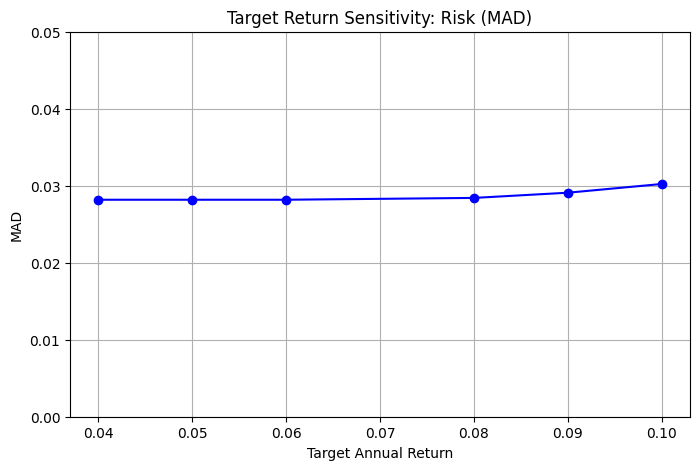

In [12]:
plot_df = results.sort_values("Target Annual Return")

x = plot_df["Target Annual Return"]
mad = plot_df["MAD"]

plt.figure(figsize=(8,5))

plt.plot(x, mad, marker="o", color="blue")

plt.xlabel("Target Annual Return")
plt.ylabel("MAD")
plt.title("Target Return Sensitivity: Risk (MAD)")

plt.grid(True)
plt.ylim(bottom=0)
plt.ylim(top=0.05) # We actually wanted the range to be wide enough and starting from 0 too to see how small the increase in risk (MAD) is, if it was smaller then we'd misinterpret probably 
plt.show()

- Riskiness is not increasing significantly even after target return becomes binding

# Lets see if its a good idea to support "domestic" stocks more so increase min possible precentage from 10 up to 25
## Conducting sensitivity analysis
basically we have the same algorithm just different variable in the following code for that reason

In [13]:
# 1. Preparing the data
R = monthly_returns.copy()

assets = R.columns.tolist()
T = len(R)

mu = R.mean()

bonds = ["IEF", "TLT"]
domestic = ["BOG", "TBC", "CGEO"]

bond_cap = {"IEF": 0.12, "TLT": 0.12}
epsilon = 0.01

target_annual = 0.04
target_monthly = (1 + target_annual) ** (1 / 12) - 1

# 2. Defining the model function
# (Bewlo we actually turn the model into a function because we will run it for different target returns)
def solve_portfolio(domestic_min):

    # 2.1 Setting the model up
    m = pyo.ConcreteModel()

    m.I = pyo.Set(initialize=assets)
    m.T = pyo.RangeSet(0, T - 1)

    # 2.2 Defining decision variables
    m.w = pyo.Var(m.I, domain=pyo.NonNegativeReals)   # portfolio weights
    m.z = pyo.Var(m.T, domain=pyo.NonNegativeReals)   # MAD deviations

    # 2.3 Objective function (we minimize MAD)
    m.obj = pyo.Objective(expr=sum(m.z[t] for t in m.T), sense=pyo.minimize)

    # 2.4 Budget constraint
    m.budget = pyo.Constraint(expr=sum(m.w[i] for i in m.I) == 1)

    # 2.5 MAD linearization
    m.dev_pos = pyo.Constraint(m.T, rule=lambda m, t:
        m.z[t] >= sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
    )

    m.dev_neg = pyo.Constraint(m.T, rule=lambda m, t:
        m.z[t] >= -sum(m.w[i] * (R.iloc[t][i] - mu[i]) for i in m.I)
    )

    # 2.6 Equity caps
    m.cap = pyo.Constraint(m.I, rule=lambda m, i:
        pyo.Constraint.Skip if i in bonds else m.w[i] <= 0.10
    )

    # 2.7 Bond caps
    m.bond_cap = pyo.Constraint(m.I, rule=lambda m, i:
        m.w[i] <= bond_cap[i] if i in bond_cap else pyo.Constraint.Skip
    )

    # 2.8 Domestic constraint (sensitivity parameter)
    m.domestic = pyo.Constraint(
        expr=sum(m.w[i] for i in domestic) >= domestic_min
    )

    # 2.9 Domestic minimum exposure
    m.domestic_min = pyo.Constraint(m.I, rule=lambda m, i:
        m.w[i] >= epsilon if i in domestic else pyo.Constraint.Skip
    )

    # 2.10 Bond constraint
    m.bonds = pyo.Constraint(expr=sum(m.w[i] for i in bonds) >= 0.20)

    # 2.11 Target return constraint
    m.target = pyo.Constraint(
        expr=sum(m.w[i] * mu[i] for i in m.I) >= target_monthly
    )

    # 2.12 Solving the model
    Highs().solve(m)

    # 2.13 Extracting results
    w = pd.Series({i: pyo.value(m.w[i]) for i in m.I})

    # 2.14 Returning scenario results
    return {
        "Domestic Min": domestic_min,
        "Expected Annual Return": (1 + np.dot(w, mu)) ** 12 - 1,
        "MAD": sum(pyo.value(m.z[t]) for t in m.T) / T,
        **w.to_dict()
    }

# List for sensitivity analysis (Domestic minimum investment level (proportion))
domestic_levels = [0.05, 0.10, 0.15, 0.20, 0.25]

results = pd.DataFrame([solve_portfolio(d) for d in domestic_levels])

# The summary table:
summary = results[["Domestic Min", "Expected Annual Return", "MAD"]]

print("\nDomestic Constraint Sensitivity\n")
print(summary.round(4))


# The weights table:

weights = results.set_index("Domestic Min").drop(
    columns=["Expected Annual Return", "MAD"]
)

# ordering assets by average allocation across scenarios
order = weights.mean().sort_values(ascending=False).index
weights = weights[order]

print("\nScenario Weights\n")
print(weights.T)


Domestic Constraint Sensitivity

   Domestic Min  Expected Annual Return     MAD
0          0.05                  0.0678  0.0281
1          0.10                  0.0720  0.0282
2          0.15                  0.0819  0.0285
3          0.20                  0.0898  0.0292
4          0.25                  0.1024  0.0306

Scenario Weights

Domestic Min      0.05      0.10     0.15      0.20  0.25
TLT           0.120000  0.120000  0.12000  0.120000  0.12
IEF           0.120000  0.120000  0.12000  0.120000  0.12
VPL           0.100000  0.100000  0.10000  0.100000  0.10
IVV           0.100000  0.100000  0.10000  0.100000  0.10
KO            0.100000  0.100000  0.10000  0.100000  0.10
SPY           0.100000  0.100000  0.10000  0.100000  0.10
VWO           0.100000  0.100000  0.10000  0.100000  0.10
CGEO          0.039810  0.051592  0.09521  0.094835  0.10
VGK           0.100000  0.100000  0.10000  0.060000  0.01
TBC           0.028489  0.038408  0.04479  0.095165  0.10
ILF           0.06625

# **As we can see by increasing minimum share of domestic stocks BOG, TBC and Georgia Capital overall riskiness of the portfolio increases according to MAD**

# **Worst case scenario , (*Robust optimization , though we realisticly have lower bound for constraint parameters only*)**

- ## Here we're using the lowest prices of each stock each day, which we'll use to then derive worst case scenario monthly returns:

In [14]:
prices = pd.read_csv("pension_fund_dataset_low.csv")

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values("Date")
prices = prices.set_index("Date")

In [15]:
monthly_prices = prices.resample("ME").last()

monthly_returns_low = monthly_prices.pct_change().iloc[1:]
monthly_returns_low.head()

,INTC_low,KO_low,SPY_low,IVV_low,VGK_low,VPL_low,VWO_low,EWY_low,ILF_low,IEF_low,TLT_low,BOG_low,TBC_low,CGEO_low
Date,,,,,,,,,,,,,,
2018-06-30,-0.100981,0.014761,0.003293,0.003344,-0.026416,-0.032780,-0.053402,-0.062005,-0.061862,0.001563,0.005788,0.017696,0.031938,0.093085
2018-07-31,-0.036566,0.069268,0.034040,0.034060,0.034452,0.006721,0.037134,-0.011116,0.113188,-0.007707,-0.017180,-0.036773,0.014122,-0.059096
2018-08-31,0.004823,-0.041460,0.031778,0.031946,-0.030716,-0.010653,-0.044067,0.002698,-0.094657,0.008750,0.011124,-0.099191,-0.073340,0.047277
2018-09-30,-0.051336,0.035594,0.002281,0.002505,-0.000534,0.017947,-0.018968,0.016891,0.056998,-0.014327,-0.030358,0.043881,0.027879,0.099289
2018-10-31,0.030136,0.027192,-0.068391,-0.068196,-0.078554,-0.097884,-0.078316,-0.145965,0.035418,-0.005735,-0.034209,-0.129563,-0.049712,0.006740


# Worst case scenario model with lowest historical returns (Robustness check)

- basicaly the same model jsut with different dataset

In [16]:
# 1. Preparing the data
R = monthly_returns_low.copy().sort_index()

assets = list(R.columns)
T = len(R)

mu = R.mean()

print("Assets used:", assets)


# classifing assets (same logic as previous models, just we adapted to *_low in the "low" prices dataset)
bond_assets = [i for i in assets if i in ["IEF_low", "TLT_low"]]
domestic_assets = [i for i in assets if i in ["BOG_low", "TBC_low", "CGEO_low"]]
equity_assets = [i for i in assets if i not in bond_assets]

bond_caps = {
    "IEF_low": 0.12,
    "TLT_low": 0.12
}


# 2. Setting the model up
model = pyo.ConcreteModel()

model.I = pyo.Set(initialize=assets)
model.T = pyo.RangeSet(0, T - 1)


# 3. Defining the decision variables
model.w = pyo.Var(model.I, domain=pyo.NonNegativeReals)   # portfolio weights
model.z = pyo.Var(model.T, domain=pyo.NonNegativeReals)   # MAD deviations

# 4. Our objective function (We're minimizing MAD)
model.obj = pyo.Objective(
    expr=sum(model.z[t] for t in model.T),
    sense=pyo.minimize
)

# 5. Now let's define our constraints
# 5.1 Budget constraint
model.budget = pyo.Constraint(
    expr=sum(model.w[i] for i in model.I) == 1
)


# 5.2 MAD linearization
model.dev_pos = pyo.Constraint(model.T, rule=lambda m, t:
    m.z[t] >= sum(m.w[i] * (R.loc[R.index[t], i] - mu[i]) for i in m.I)
)

model.dev_neg = pyo.Constraint(model.T, rule=lambda m, t:
    m.z[t] >= -sum(m.w[i] * (R.loc[R.index[t], i] - mu[i]) for i in m.I)
)

# 5.3 Defining asset caps

# equity cap (only equities)
model.equity_cap = pyo.Constraint(model.I, rule=lambda m, i:
    m.w[i] <= 0.1 if i in equity_assets else pyo.Constraint.Skip
)

# bond caps (individual caps per bond ETF)
model.bond_cap = pyo.Constraint(model.I, rule=lambda m, i:
    m.w[i] <= bond_caps[i] if i in bond_caps else pyo.Constraint.Skip
)

# 5.4 Bond constraint
model.bonds = pyo.Constraint(
    expr=sum(model.w[i] for i in bond_assets) >= 0.20
)

# 5.5 Domestic constraints
model.domestic = pyo.Constraint(
    expr=sum(model.w[i] for i in domestic_assets) >= 0.10
)

epsilon = 0.01

model.domestic_min = pyo.Constraint(model.I, rule=lambda m, i:
    m.w[i] >= epsilon if i in domestic_assets else pyo.Constraint.Skip
)

# 6. Solving the model
opt = Highs()
opt.solve(model)

# 7. Obtaining results
weights_low = pd.Series({i: pyo.value(model.w[i]) for i in model.I})
weights_low = weights_low.sort_values(ascending=False)

print("\nOptimal Portfolio Weights:\n")
print(weights_low)

Assets used: ['INTC_low', 'KO_low', 'SPY_low', 'IVV_low', 'VGK_low', 'VPL_low', 'VWO_low', 'EWY_low', 'ILF_low', 'IEF_low', 'TLT_low', 'BOG_low', 'TBC_low', 'CGEO_low']

Optimal Portfolio Weights:

TLT_low     0.120000
IEF_low     0.120000
VGK_low     0.100000
IVV_low     0.100000
KO_low      0.100000
SPY_low     0.100000
VWO_low     0.100000
VPL_low     0.100000
CGEO_low    0.050400
TBC_low     0.039600
ILF_low     0.035855
INTC_low    0.024145
BOG_low     0.010000
EWY_low     0.000000
dtype: float64


- Note that this time compared to end-day prices baseline scenario now Georgia Capital in "domestic" stock world in relative terms has more share than TBC.
- Also intel share increased significantly, so relatively worst case scenario affected it less
- Note that ILF in worst case scenario became significantly riskier and less desirable and instead of ~8% now it has only ~3.6%

# Now let's see another extreme case the best case scenario when prices of stocks and bonds are at their peak per day:

In [17]:
prices = pd.read_csv("pension_fund_dataset_high.csv")

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values("Date")
prices = prices.set_index("Date")
monthly_prices = prices.resample("ME").last()

monthly_returns_high = monthly_prices.pct_change().iloc[1:]

In [18]:
monthly_returns_high.head()

,INTC_high,KO_high,SPY_high,IVV_high,VGK_high,VPL_high,VWO_high,EWY_high,ILF_high,IEF_high,TLT_high,BOG_high,TBC_high,CGEO_high
Date,,,,,,,,,,,,,,
2018-06-30,-0.102936,0.020597,0.004294,0.004338,-0.028390,-0.035611,-0.056684,-0.064165,-0.055345,-0.000584,0.004263,-0.000473,0.032699,0.028868
2018-07-31,-0.028537,0.058277,0.030549,0.030667,0.032938,0.009980,0.039981,-0.007225,0.109140,-0.008278,-0.021551,-0.024826,0.010351,-0.062714
2018-08-31,-0.002465,-0.034283,0.031168,0.031374,-0.026916,-0.010305,-0.041856,0.000743,-0.086628,0.009820,0.017187,-0.103641,-0.078134,0.030561
2018-09-30,-0.016680,0.024850,0.001616,0.001844,-0.004228,0.016688,-0.021130,0.014396,0.052214,-0.014879,-0.032890,0.042674,0.045708,0.089681
2018-10-31,0.016963,0.040918,-0.061968,-0.062023,-0.078202,-0.097643,-0.077856,-0.143819,0.037374,-0.005528,-0.033500,-0.128141,-0.024856,0.009302


### This is same type dataset just with highest returns based on highest prices during 1st and last working day of a month above

In [19]:
# 1. Preparing the data
R = monthly_returns_high.copy()

# ensuring proper ordering we had some unexpected issue
R = R.sort_index()

assets = list(R.columns)
T = len(R)

mu = R.mean()

print("Assets used:", assets)


# 2. Setting the model up
model = pyo.ConcreteModel()

model.I = pyo.Set(initialize=assets)
model.T = pyo.RangeSet(0, T - 1)


# 3. Defining the decision variables
model.w = pyo.Var(model.I, domain=pyo.NonNegativeReals)   # portfolio weights
model.z = pyo.Var(model.T, domain=pyo.NonNegativeReals)   # MAD deviations


# 4. Our objective function (We're minimizing MAD)
def obj_rule(m):
    return sum(m.z[t] for t in m.T)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)


# 5. Now let's define our constraints:
# 5.1 Budget constraint
def budget_rule(m):
    return sum(m.w[i] for i in m.I) == 1

model.budget = pyo.Constraint(rule=budget_rule)


# 5.2 MAD linearization
def dev_pos(m, t):
    return m.z[t] >= sum(
        m.w[i] * (R.loc[R.index[t], i] - mu[i])
        for i in m.I
    )

model.dev_pos = pyo.Constraint(model.T, rule=dev_pos)


def dev_neg(m, t):
    return m.z[t] >= -sum(
        m.w[i] * (R.loc[R.index[t], i] - mu[i])
        for i in m.I
    )

model.dev_neg = pyo.Constraint(model.T, rule=dev_neg)


# 5.3 Bond caps (individual caps)
bond_cap = {
    "IEF_high": 0.12,
    "TLT_high": 0.12
}

def bond_cap_rule(m, i):
    if i in bond_cap:
        return m.w[i] <= bond_cap[i]
    return pyo.Constraint.Skip

model.bond_cap = pyo.Constraint(model.I, rule=bond_cap_rule)


# 5.4 Equity caps (all non-bonds like in base primal of course)
def cap_rule(m, i):
    if i in bond_cap:
        return pyo.Constraint.Skip
    return m.w[i] <= 0.1

model.cap = pyo.Constraint(model.I, rule=cap_rule)


# 5.5 Bond constraint (constructed from asset names)
bonds_base = ["IEF_high", "TLT_high"]
bonds = [i for i in assets if any(i.startswith(x) for x in bonds_base)]

def bond_rule(m):
    return sum(m.w[i] for i in bonds) >= 0.20

model.bonds = pyo.Constraint(rule=bond_rule)


# 5.6 Domestic constraints
domestic_base = ["BOG_high", "TBC_high", "CGEO_high"]
domestic = [i for i in assets if any(i.startswith(x) for x in domestic_base)]

def domestic_rule(m):
    return sum(m.w[i] for i in domestic) >= 0.10

model.domestic = pyo.Constraint(rule=domestic_rule)

epsilon = 0.01

def domestic_min_rule(m, i):
    if i in domestic:
        return m.w[i] >= epsilon
    return pyo.Constraint.Skip

model.domestic_min = pyo.Constraint(model.I, rule=domestic_min_rule)


# 6. Solving the model
opt = Highs()
result = opt.solve(model)


# 7. Obtaining our final results
weights_high = pd.Series({i: pyo.value(model.w[i]) for i in model.I})
weights_high = weights_high.sort_values(ascending=False)

print("\nOptimal Portfolio Weights:\n")
print(weights_high)

Assets used: ['INTC_high', 'KO_high', 'SPY_high', 'IVV_high', 'VGK_high', 'VPL_high', 'VWO_high', 'EWY_high', 'ILF_high', 'IEF_high', 'TLT_high', 'BOG_high', 'TBC_high', 'CGEO_high']

Optimal Portfolio Weights:

TLT_high     0.120000
IEF_high     0.120000
VGK_high     0.100000
IVV_high     0.100000
KO_high      0.100000
SPY_high     0.100000
VWO_high     0.100000
VPL_high     0.100000
ILF_high     0.055414
CGEO_high    0.051807
TBC_high     0.038193
BOG_high     0.010000
INTC_high    0.004586
EWY_high     0.000000
dtype: float64


In [20]:
weights_base # These are column vectors of our optimal solutions we obteined in aboce code sections
weights_low
weights_high
# Removing scenario suffixes
weights_low.index = weights_low.index.str.replace("_low", "", regex=False)

weights_high.index = weights_high.index.str.replace("_high", "", regex=False)

# Building comparison table
comparison_table = pd.concat(
    [weights_base, weights_low, weights_high],
    axis=1
)

comparison_table.columns = [
    "Baseline",
    "Low Scenario",
    "High Scenario"
]

comparison_table = comparison_table.fillna(0)

# Sorting by importance (largest baseline weight first so that we see the differences easily)
comparison_table["Importance"] = comparison_table["Baseline"]
comparison_table = comparison_table.sort_values(
    "Importance",
    ascending=False
).drop(columns="Importance")

print(comparison_table)

      Baseline  Low Scenario  High Scenario
TLT   0.120000      0.120000       0.120000
IEF   0.120000      0.120000       0.120000
VGK   0.100000      0.100000       0.100000
IVV   0.100000      0.100000       0.100000
KO    0.100000      0.100000       0.100000
SPY   0.100000      0.100000       0.100000
VWO   0.100000      0.100000       0.100000
VPL   0.100000      0.100000       0.100000
CGEO  0.051592      0.050400       0.051807
ILF   0.049998      0.035855       0.055414
TBC   0.038408      0.039600       0.038193
INTC  0.010002      0.024145       0.004586
BOG   0.010000      0.010000       0.010000
EWY   0.000000      0.000000       0.000000


### We're finally going with baseline scenario since end day prices are usually more probable to be determining future prices rather than extreme cases of lows and highs

In [21]:
weights_base

INTC    0.010002
KO      0.100000
SPY     0.100000
IVV     0.100000
VGK     0.100000
VPL     0.100000
VWO     0.100000
EWY     0.000000
ILF     0.049998
IEF     0.120000
TLT     0.120000
BOG     0.010000
TBC     0.038408
CGEO    0.051592
dtype: float64

# Pie chart representing the distribution

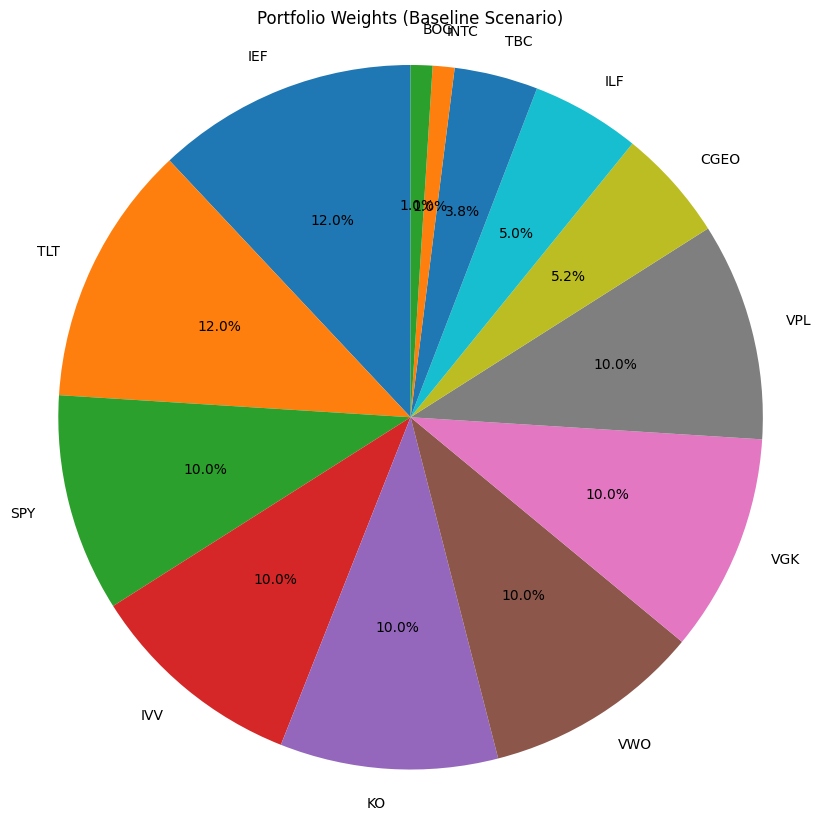

In [22]:
# Here we remoce weight which has 0 , actually it was only one so we just say take weight non zero and positive below :
w = weights_base[weights_base > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 10))

plt.pie(
    w.values,
    labels=w.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Portfolio Weights (Baseline Scenario)")
plt.axis("equal")

plt.show()

# Efficient frontier
## The graph of the efficient frontier:

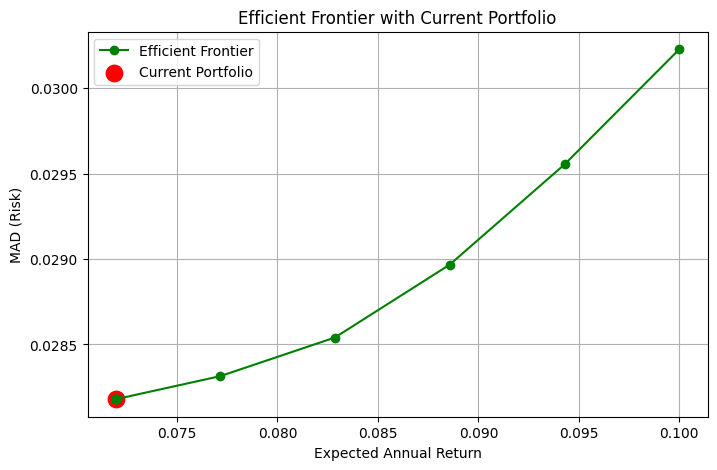

    target     MAD  return
0   0.0200  0.0282  0.0720
1   0.0257  0.0282  0.0720
2   0.0314  0.0282  0.0720
3   0.0371  0.0282  0.0720
4   0.0429  0.0282  0.0720
5   0.0486  0.0282  0.0720
6   0.0543  0.0282  0.0720
7   0.0600  0.0282  0.0720
8   0.0657  0.0282  0.0720
9   0.0714  0.0282  0.0720
10  0.0771  0.0283  0.0771
11  0.0829  0.0285  0.0829
12  0.0886  0.0290  0.0886
13  0.0943  0.0296  0.0943
14  0.1000  0.0302  0.1000


In [23]:
R = monthly_returns.copy() 

assets = R.columns.tolist()
T = len(R)  # number of time periods
mu = R.mean()  # mean return of each asset , kind of expected, average one 

bonds = ["IEF", "TLT"]  # bond assets in the portfolio
domestic = ["BOG", "TBC", "CGEO"]  # domestic equity subset

bond_cap = {"IEF": 0.12, "TLT": 0.12}  # max weight caps for individual bonds
epsilon = 0.01  # minimum allocation for selected assets (To remind we had it for Georgian related ones)

# 2. Creating model function like in previous cases
def solve_portfolio(target_annual):

    target_monthly = (1 + target_annual)**(1/12) - 1  # converting annual target return to monthly

    m = pyo.ConcreteModel()  # creating pyomo optimization model

    m.I = pyo.Set(initialize=assets)  # asset index set
    m.T = pyo.RangeSet(0, T-1)  # time index set for MAD deviations

    m.w = pyo.Var(m.I, domain=pyo.NonNegativeReals)  # portfolio weights
    m.z = pyo.Var(m.T, domain=pyo.NonNegativeReals) 

    # Objective (MAD)
    m.obj = pyo.Objective(expr=sum(m.z[t] for t in m.T), sense=pyo.minimize)  # obj is to minimize mean absolute deviation

    # Budget
    m.budget = pyo.Constraint(expr=sum(m.w[i] for i in m.I) == 1) # investment constraint

    # MAD constraints
    m.dev_pos = pyo.Constraint(m.T, rule=lambda m,t:
        m.z[t] >= sum(m.w[i]*(R.iloc[t][i] - mu[i]) for i in m.I)
    )

    m.dev_neg = pyo.Constraint(m.T, rule=lambda m,t:
        m.z[t] >= -sum(m.w[i]*(R.iloc[t][i] - mu[i]) for i in m.I)  
    )

    # Equity cap
    m.cap = pyo.Constraint(m.I, rule=lambda m,i:
        pyo.Constraint.Skip if i in bonds else m.w[i] <= 0.10  # cap for equities at 10%
    )

    # Bond caps
    m.bond_cap = pyo.Constraint(m.I, rule=lambda m,i:
        m.w[i] <= bond_cap[i] if i in bond_cap else pyo.Constraint.Skip  # individual bond limits
    )

    # Domestic constraint
    m.domestic = pyo.Constraint(expr=sum(m.w[i] for i in domestic) >= 0.10)  # minimum domestic investment

    m.domestic_min = pyo.Constraint(m.I, rule=lambda m,i:
        m.w[i] >= epsilon if i in domestic else pyo.Constraint.Skip 
    )

    # Bond minimum
    m.bonds = pyo.Constraint(expr=sum(m.w[i] for i in bonds) >= 0.20)  # minimum bond allocation

    # Target return
    m.target = pyo.Constraint(expr=sum(m.w[i]*mu[i] for i in m.I) >= target_monthly)  # return constraint

    Highs().solve(m)  # obviously solving optimization model using HiGHS solver

    w = pd.Series({i: pyo.value(m.w[i]) for i in m.I})  # extracting optimal weights

    return {
        "target": target_annual, 
        "MAD": sum(pyo.value(m.z[t]) for t in m.T) / T, 
        "return": (1 + np.dot(w, mu))**12 - 1  # annualized expected return
    }

# The efficient frontier
targets = np.linspace(0.02, 0.10, 15)  

results = pd.DataFrame([solve_portfolio(t) for t in targets])  

# This is baseline portfolio below, the current point on the graph:
w_base = weights_base  

base_return = (1 + np.dot(w_base, mu))**12 - 1  # annualized return of baseline portfolio

dev = (R - mu).dot(w_base)  # deviation of returns from mean under base weights
base_mad = np.mean(np.abs(dev))  # MAD of baseline portfolio

# The plot
plt.figure(figsize=(8,5)) 

# Efficient frontier
plt.plot(
    results["return"],
    results["MAD"],
    marker="o",
    color="green",
    label="Efficient Frontier"
)

# Current portfolio (the red point on our graph)
plt.scatter(
    base_return,
    base_mad,
    color="red",
    s=140,
    label="Current Portfolio"  # this is baseline comparison point
)

plt.xlabel("Expected Annual Return") 
plt.ylabel("MAD (Risk)") 
plt.title("Efficient Frontier with Current Portfolio")
plt.grid(True)  
plt.legend()  
plt.show()  
# printing the output table belwo the graph:
print(results.round(4)) 

In [24]:
weights_base

INTC    0.010002
KO      0.100000
SPY     0.100000
IVV     0.100000
VGK     0.100000
VPL     0.100000
VWO     0.100000
EWY     0.000000
ILF     0.049998
IEF     0.120000
TLT     0.120000
BOG     0.010000
TBC     0.038408
CGEO    0.051592
dtype: float64

- ## Interestingly we are at the lowest risk point of the frontier and lowest return though its efficient and for pension fund could be acceptable given return providing consitions for giving positive real return per year.

## Allocation of an Additional $1 Million Investment (Pension Fund Portfolio)

If the pension fund receives an additional **$1,000,000**, the capital is allocated according to the optimized MAD minimizing portfolio weights given risk and return constraints.

### Optimal Portfolio Weights and Dollar Allocation table :

| Asset | Weight | Allocation (USD) |
|------|--------|------------------|
| **INTC** | 0.010002 | $10,002 |
| **KO**   | 0.100000 | $100,000 |
| **SPY**  | 0.100000 | $100,000 |
| **IVV**  | 0.100000 | $100,000 |
| **VGK**  | 0.100000 | $100,000 |
| **VPL**  | 0.100000 | $100,000 |
| **VWO**  | 0.100000 | $100,000 |
| **EWY**  | 0.000000 | $0 |
| **ILF**  | 0.049998 | $49,998 |
| **IEF**  | 0.120000 | $120,000 |
| **TLT**  | 0.120000 | $120,000 |
| **BOG**  | 0.010000 | $10,000 |
| **TBC**  | 0.038408 | $38,404 |
| **CGEO** | 0.051592 | $51,592 |

---

### Our overall interpretation of the results we achieved

- As you can see our portfolio is broadly diversified across global equity ETFs, many of which hit the **10% cap constraint**.
- Government bonds (IEF & TLT) receive a substantial allocation so they apparently play vital role in stabilizing risk.
- INTC and BOG receive minimal allocation, probably because BOG is the riskiest one and Intel has small marginal return compared to its competetitor assets
- EWY is excluded in this optimal solution , apparently due to the fact that compared to other regional equity ETFs Korean ETF is riskier and has small return

---

## **Our vital Insight**

<span style="color:green; font-size:24px;">
So, Additional $1 million investment is primarily distributed into diversified equity ETFs and long-term bonds, which is actually consistent with a risk-averse allocation strategy while using MAD. However, we kind of balanced that primary focus on risk minimization by introducing minimum required return, though in final model it was not binding we showed that at ~8% it becomes binding and we can push our model to higher min return.
</span>

- The portfolio generates an expected **monthly return of ~0.58%**, which compounds to an annualized return of approximately **7.20%**.
- This return level is achieved under strict risk control using a **Mean Absolute Deviation (MAD) minimization framework**, meaning the model prioritizes stability over extreme return maximization.
- The resulting return is consistent with a **diversified institutional portfolio**, balancing global equities and long-duration bonds under allocation constraints.

---

### 
The optimization indicates that stable, diversified exposure can still achieve a **~7% annual return profile** while maintaining controlled downside variability under MAD-based risk minimization.

# Let's get back to some improtant findings in main model such as:

- ### The portfolio generates an expected **monthly return of ~0.58%**, which compounds to an annualized return of approximately **7.19%**.
### **`As a result:`**
<span style="color:red; font-size:24px;">
The optimization indicates that stable, diversified exposure can still achieve a more than 7% annual return profile while maintaining controlled downside variability under MAD-based risk minimization.
</span>

In [25]:
((1+0.0719)/(1+0.038))-1 # <- Calculating real return here

0.03265895953757236

### Note that in 2026 expected inflation of US dollar is around 3.8% in worst case scenario , so we'd expect ~3.26% real return from this investment portfolio at the end of this year.

<div style="text-align:center; font-size:36px; color:green;">
The End
</div>